Pearson r  : 0.9179
p-value    : 0.000000
Slope      : 5.3605
Intercept  : 10390.57


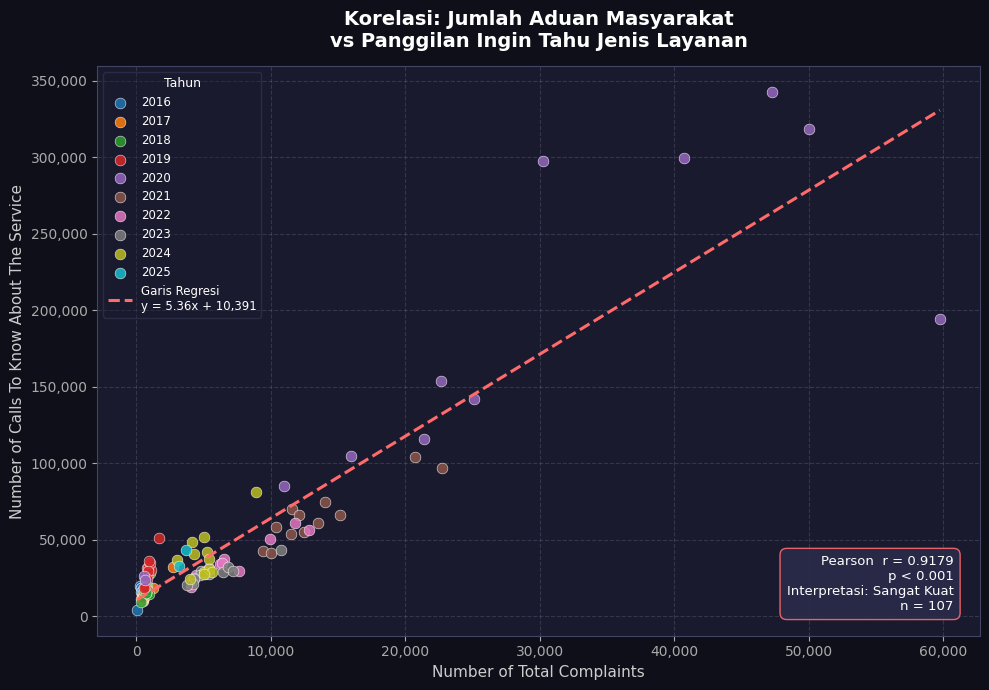

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy import stats

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(r'D:\tugas-kuliah\alprog\post test gwej\Kelas G_Fixed Call Report (1).csv')
x = df['Number of Total Complaints']
y = df['Number of Calls To Know About The Service']

# ── 2. Statistik korelasi ─────────────────────────────────────────────────────
r, p_val   = stats.pearsonr(x, y)
slope, intercept, *_ = stats.linregress(x, y)
x_line     = np.linspace(x.min(), x.max(), 300)
y_line     = slope * x_line + intercept

print(f"Pearson r  : {r:.4f}")
print(f"p-value    : {p_val:.6f}")
print(f"Slope      : {slope:.4f}")
print(f"Intercept  : {intercept:.2f}")

# ── 3. Warna per tahun ────────────────────────────────────────────────────────
years     = sorted(df['Year'].unique())
palette   = sns.color_palette("tab10", len(years))
color_map = dict(zip(years, palette))

# ── 4. Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0F0F1A')
ax.set_facecolor('#1A1A2E')

# Scatter — warna berbeda tiap tahun
for yr in years:
    mask = df['Year'] == yr
    ax.scatter(x[mask], y[mask],
               color=color_map[yr], s=60, alpha=0.85,
               edgecolors='white', linewidths=0.4,
               label=str(yr), zorder=3)

# Garis regresi linear
ax.plot(x_line, y_line, color='#FF6B6B', linewidth=2.2,
        linestyle='--',
        label=f'Garis Regresi\ny = {slope:.2f}x + {intercept:,.0f}',
        zorder=4)

# ── 5. Anotasi korelasi ───────────────────────────────────────────────────────
interp = "Sangat Kuat" if abs(r) >= 0.8 else "Kuat" if abs(r) >= 0.6 else "Sedang"
p_str  = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.4f}"
box_txt = (f"Pearson  r = {r:.4f}\n"
           f"{p_str}\n"
           f"Interpretasi: {interp}\n"
           f"n = {len(df)}")
ax.text(0.97, 0.04, box_txt,
        transform=ax.transAxes, fontsize=9.5,
        verticalalignment='bottom', horizontalalignment='right',
        color='white',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#2A2A4A',
                  edgecolor='#FF6B6B', alpha=0.9))

# ── 6. Styling ────────────────────────────────────────────────────────────────
ax.set_title('Korelasi: Jumlah Aduan Masyarakat\nvs Panggilan Ingin Tahu Jenis Layanan',
             color='white', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Number of Total Complaints', color='#CCCCCC', fontsize=11)
ax.set_ylabel('Number of Calls To Know About The Service',
              color='#CCCCCC', fontsize=11)

ax.tick_params(colors='#AAAAAA')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
for spine in ax.spines.values():
    spine.set_edgecolor('#444466')
ax.grid(True, linestyle='--', alpha=0.25, color='#8888AA')

legend = ax.legend(title='Tahun', title_fontsize=9, fontsize=8.5,
                   framealpha=0.3, facecolor='#1A1A2E',
                   edgecolor='#555577', labelcolor='white',
                   loc='upper left')
legend.get_title().set_color('white')

plt.tight_layout()
plt.savefig('scatter_korelasi.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()